In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e5/train.csv
/kaggle/input/competitions/playground-series-s6e5/test.csv


# Load dataset and Initial processing

In [2]:
data= pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/train.csv')
df= data

In [3]:
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
df.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [5]:
df.shape

(439140, 16)

In [6]:
df.drop(inplace= True, columns= ['id'], axis= 1)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap          

In [8]:
def get_unique_count(df, col):
    return df[col].nunique()

def get_dtype(df, col):
    return df[col].dtype


for col in df.columns:
    print(f"{col} - {get_unique_count(df, col)} - {get_dtype(df, col)}")

print(f"Duplicates: {df.duplicated().sum()}\n")

print(df['PitNextLap'].value_counts())

num_cols= df.select_dtypes(include=['number']).columns.tolist()
cat_cols= df.select_dtypes(exclude=['number']).columns.tolist()

Driver - 887 - object
Compound - 5 - object
Race - 26 - object
Year - 4 - int64
PitStop - 2 - int64
LapNumber - 78 - int64
Stint - 8 - int64
TyreLife - 78 - float64
Position - 20 - int64
LapTime (s) - 37719 - float64
LapTime_Delta - 57532 - float64
Cumulative_Degradation - 142701 - float64
RaceProgress - 1898 - float64
Position_Change - 37 - float64
PitNextLap - 2 - float64
Duplicates: 0

PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64


# Plots

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

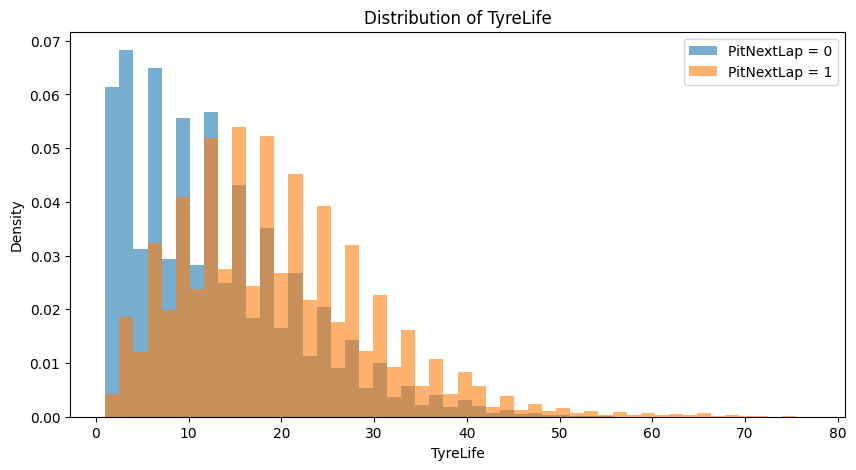

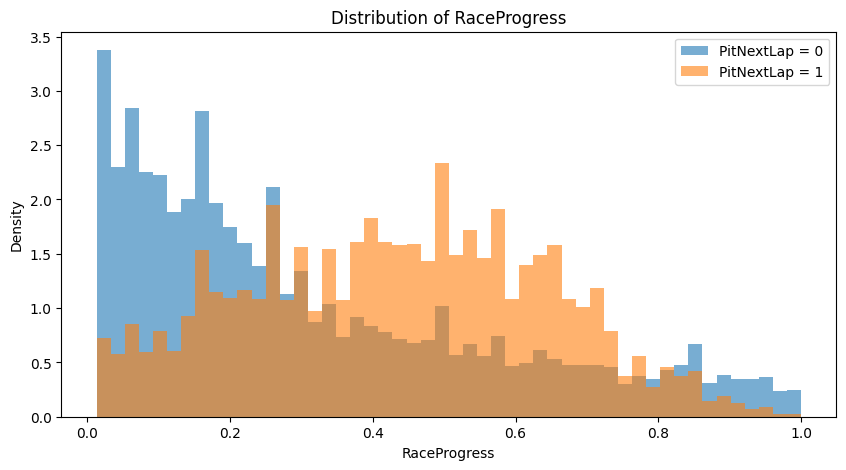

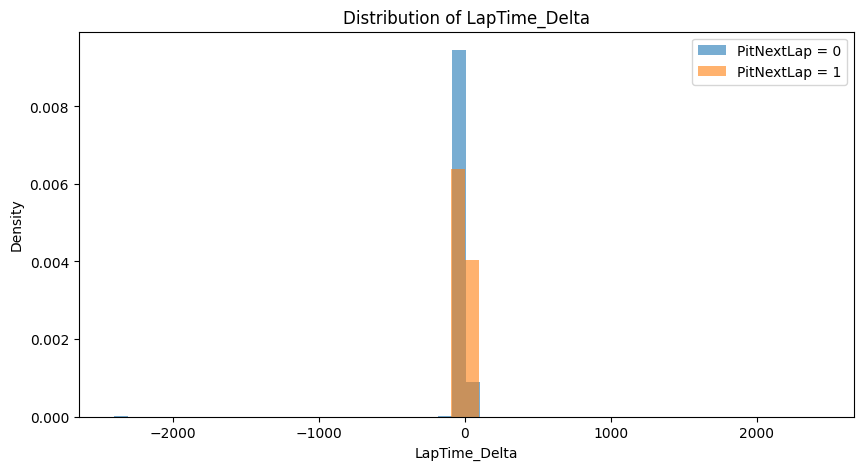

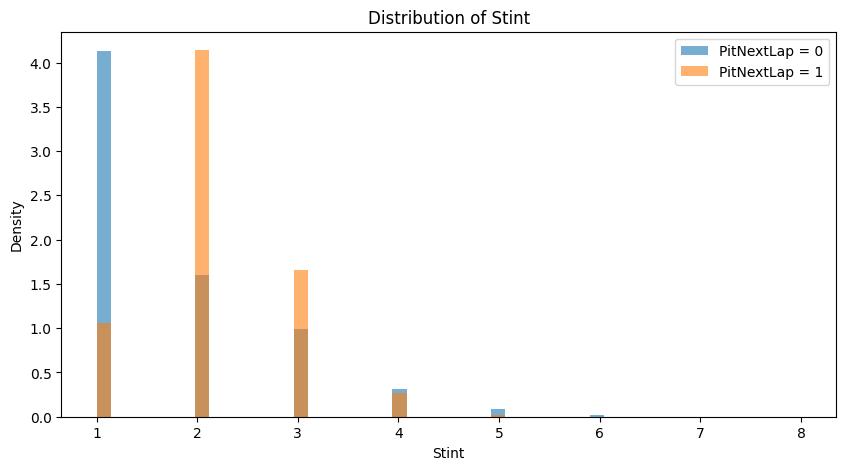

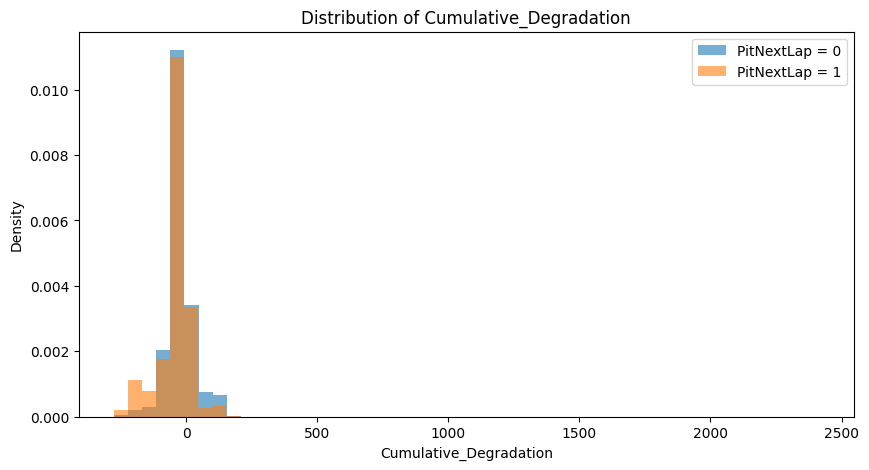

In [10]:
features = [
    'TyreLife',
    'RaceProgress',
    'LapTime_Delta',
    'Stint',
    'Cumulative_Degradation'
]


pit_0 = df[df['PitNextLap'] == 0]
pit_1 = df[df['PitNextLap'] == 1]

for feature in features:
    
    plt.figure(figsize=(10, 5))
    
    plt.hist(
        pit_0[feature],
        bins=50,
        alpha=0.6,
        density=True,
        label='PitNextLap = 0'
    )
    
    plt.hist(
        pit_1[feature],
        bins=50,
        alpha=0.6,
        density=True,
        label='PitNextLap = 1'
    )
    
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend()
    plt.show()

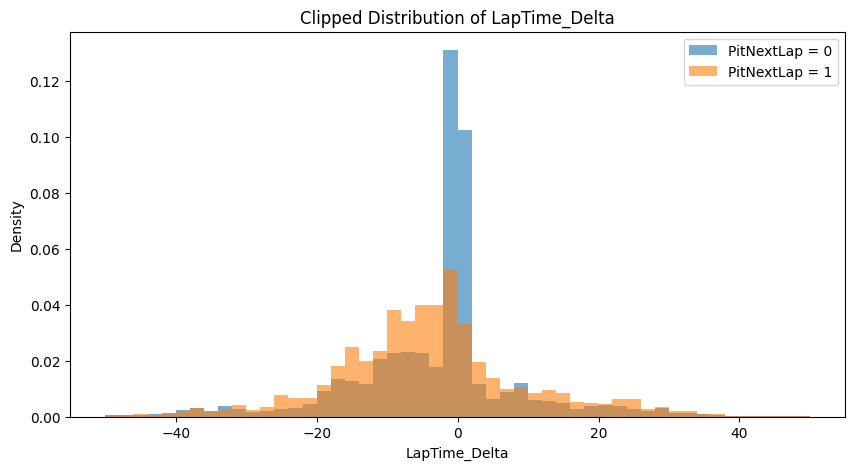

In [11]:
clipped_df = df[
    (df['LapTime_Delta'] > -50) &
    (df['LapTime_Delta'] < 50)
]

pit_0 = clipped_df[clipped_df['PitNextLap'] == 0]
pit_1 = clipped_df[clipped_df['PitNextLap'] == 1]

plt.figure(figsize=(10, 5))

plt.hist(
    pit_0['LapTime_Delta'],
    bins=50,
    alpha=0.6,
    density=True,
    label='PitNextLap = 0'
)

plt.hist(
    pit_1['LapTime_Delta'],
    bins=50,
    alpha=0.6,
    density=True,
    label='PitNextLap = 1'
)

plt.title('Clipped Distribution of LapTime_Delta')
plt.xlabel('LapTime_Delta')
plt.ylabel('Density')
plt.legend()

plt.show()

In [12]:
corr_mat= df[num_cols].corr()
corr_mat

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
Year,1.000000,0.090767,0.008556,-0.055644,0.041472,0.039931,-0.047048,-0.011863,0.036667,-0.068874,0.008429,0.125267
PitStop,0.090767,1.000000,0.111431,0.143869,-0.134678,0.093536,-0.000437,-0.008458,-0.088052,0.059177,-0.107659,0.048567
LapNumber,0.008556,0.111431,1.000000,0.724390,0.648408,0.001951,-0.128485,0.031275,-0.173135,0.964539,0.010347,0.267057
Stint,-0.055644,0.143869,0.724390,1.000000,0.157733,0.151200,-0.068869,0.017193,-0.118171,0.710020,-0.014225,0.198193
TyreLife,0.041472,-0.134678,0.648408,0.157733,1.000000,-0.120744,-0.133304,0.035947,-0.111742,0.622660,0.052309,0.273510
Position,0.039931,0.093536,0.001951,0.151200,-0.120744,1.000000,0.017899,-0.012633,-0.026649,0.006937,-0.316446,0.021348
LapTime (s),-0.047048,-0.000437,-0.128485,-0.068869,-0.133304,0.017899,1.000000,0.138818,0.205705,-0.094317,-0.002352,-0.034096
LapTime_Delta,-0.011863,-0.008458,0.031275,0.017193,0.035947,-0.012633,0.138818,1.000000,0.053713,0.036777,0.005837,-0.004946
Cumulative_Degradation,0.036667,-0.088052,-0.173135,-0.118171,-0.111742,-0.026649,0.205705,0.053713,1.000000,-0.137938,-0.000067,-0.167401
RaceProgress,-0.068874,0.059177,0.964539,0.710020,0.622660,0.006937,-0.094317,0.036777,-0.137938,1.000000,0.008852,0.185477


In [13]:
corr_mat_target= df[num_cols].corrwith(df['PitNextLap'])
corr_mat_target.abs().sort_values(ascending= False)

PitNextLap                1.000000
TyreLife                  0.273510
LapNumber                 0.267057
Stint                     0.198193
RaceProgress              0.185477
Cumulative_Degradation    0.167401
Year                      0.125267
PitStop                   0.048567
Position_Change           0.046230
LapTime (s)               0.034096
Position                  0.021348
LapTime_Delta             0.004946
dtype: float64

# Models

In [14]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

## Checkpoint - baseline features

In [15]:
features= ['Race', 'Driver', 'LapTime_Delta','LapNumber', 'TyreLife', 'Stint', 'Compound', 'Position_Change', 'PitNextLap', 'RaceProgress', 'Cumulative_Degradation']

df_baseline= df[features]
df_baseline= df_baseline.join(pd.get_dummies(df_baseline['Compound'], drop_first= True).astype(int))
df_baseline.drop(columns= 'Compound', inplace= True)

df_baseline= df_baseline.sort_values(by= ['Race', 'Driver', 'LapNumber']).reset_index(drop= True)
df_baseline= df_baseline.drop_duplicates(subset= ['Race', 'Driver', 'LapNumber'], keep='last').reset_index(drop=True)
df_baseline['LTD_RollingMean3Lap']= (df_baseline.groupby(['Race', 'Driver'])['LapTime_Delta'].transform(lambda x: x.shift(1).rolling(window= 3, min_periods= 1).mean()))

df_baseline['LTD_Velocity3Lap']= (df_baseline.groupby(['Race', 'Driver'])['LapTime_Delta'].transform(lambda x: x.shift(1).diff(periods= 1).rolling(window= 3, min_periods= 1).mean()))

df_baseline.head()

,Race,Driver,LapTime_Delta,LapNumber,TyreLife,Stint,Position_Change,PitNextLap,RaceProgress,Cumulative_Degradation,INTERMEDIATE,MEDIUM,SOFT,WET,LTD_RollingMean3Lap,LTD_Velocity3Lap
0,Abu Dhabi Grand Prix,ALB,-24.966,1,1.0,1,-6.0,0.0,0.012987,-7.055,0,1,0,0,NaN,NaN
1,Abu Dhabi Grand Prix,ALB,-10.600,2,3.0,1,8.0,0.0,0.026316,-27.222,0,1,0,0,-24.966000,NaN
2,Abu Dhabi Grand Prix,ALB,-43.090,3,4.0,1,-3.0,0.0,0.039474,-25.328,0,1,0,0,-17.783000,14.366
3,Abu Dhabi Grand Prix,ALB,-0.858,4,7.0,1,-1.0,0.0,0.051948,-35.036,0,1,0,0,-26.218667,-9.062
4,Abu Dhabi Grand Prix,ALB,-1.354,5,10.0,1,-1.0,0.0,0.086207,-8.729,0,1,0,0,-18.182667,8.036


## Creating validation splits

### Checkpoint - add more engineered features

In [16]:
features= ['Race', 'Driver', 'LapTime_Delta','LapNumber', 'TyreLife', 'Stint', 'Compound', 'Position_Change', 'PitNextLap', 'RaceProgress', 'Cumulative_Degradation']
df_engineered= df_baseline.copy()


df_engineered= df_engineered.sort_values(by= ['Race', 'Driver', 'LapNumber']).reset_index(drop= True)

# stint progression ratio
df_engineered['StintProgressRatio']= df_engineered['TyreLife'] / (df_engineered['LapNumber'] + 1e-5)

# peak pit window
df_engineered['Is_Peak_Pit_Window'] = df_engineered['LapNumber'].between(15, 25).astype(int) | df_engineered['LapNumber'].between(28, 38).astype(int)

# estimated compound wear
def estimate_compound_wear(row):
    if row['SOFT'] == 1:
        return row['TyreLife'] / 18.0
    elif row['MEDIUM'] == 1:
        return row['TyreLife'] / 28.0
    else:
        return row['TyreLife'] / 45.0

df_engineered['Estimated_Compound_Wear'] = df_baseline.apply(estimate_compound_wear, axis=1)

In [17]:
df_engineered.head(3)

,Race,Driver,LapTime_Delta,LapNumber,TyreLife,Stint,Position_Change,PitNextLap,RaceProgress,Cumulative_Degradation,INTERMEDIATE,MEDIUM,SOFT,WET,LTD_RollingMean3Lap,LTD_Velocity3Lap,StintProgressRatio,Is_Peak_Pit_Window,Estimated_Compound_Wear
0,Abu Dhabi Grand Prix,ALB,-24.966,1,1.0,1,-6.0,0.0,0.012987,-7.055,0,1,0,0,NaN,NaN,0.999990,0,0.035714
1,Abu Dhabi Grand Prix,ALB,-10.600,2,3.0,1,8.0,0.0,0.026316,-27.222,0,1,0,0,-24.966,NaN,1.499993,0,0.107143
2,Abu Dhabi Grand Prix,ALB,-43.090,3,4.0,1,-3.0,0.0,0.039474,-25.328,0,1,0,0,-17.783,14.366,1.333329,0,0.142857


In [18]:
# LGBM
from sklearn.model_selection import StratifiedGroupKFold

groups= df_engineered['Race'].values
target= 'PitNextLap'
y= df_engineered[target].values
train_features= ['RaceProgress', 'TyreLife', 'Stint', 'Position_Change', 'INTERMEDIATE', 
                'MEDIUM', 'SOFT', 'WET', 'LTD_RollingMean3Lap', 'LTD_Velocity3Lap', 
                'Cumulative_Degradation', 'StintProgressRatio', 'Is_Peak_Pit_Window', 'Estimated_Compound_Wear']
    
sgkf= StratifiedGroupKFold(n_splits= 5)
lgbm_trained_models= []
    
for fold, (train_idx, val_idx) in enumerate(sgkf.split(df_engineered, y, groups=groups)):
    print(f"--->LGBM Fold {fold + 1}<---")
        
    lgbm_model= LGBMClassifier(
        objective= 'binary',
        metrics= 'auc',
        n_estimators= 2000,
        random_state= 7 + fold,
        n_jobs= -1,
        learning_rate= 0.03,
        num_leaves= 31,
        max_depth= 6,
        min_data_in_leaf= 50,
        bagging_fraction=0.8,
        bagging_freq=1,
        feature_fraction=0.8, 
        verbose= -1
    )
            
    x_train= df_engineered.iloc[train_idx][train_features]
    y_train= y[train_idx]
        
    x_val= df_engineered.iloc[val_idx][train_features]
    y_val= y[val_idx]
        
    lgbm_model.fit(x_train, y_train,
                eval_set= [(x_val, y_val)],
                callbacks= [early_stopping(stopping_rounds= 50),
                                log_evaluation(period= 100)])
    lgbm_trained_models.append(lgbm_model)
            

print(f"--->All LGBM folds completed<---")

--->LGBM Fold 1<---
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.890232
[200]	valid_0's auc: 0.896142
[300]	valid_0's auc: 0.89845
[400]	valid_0's auc: 0.900079
[500]	valid_0's auc: 0.901314
[600]	valid_0's auc: 0.901991
[700]	valid_0's auc: 0.902492
[800]	valid_0's auc: 0.902929
[900]	valid_0's auc: 0.903191
[1000]	valid_0's auc: 0.903359
[1100]	valid_0's auc: 0.903566
Early stopping, best iteration is:
[1149]	valid_0's auc: 0.903641
--->LGBM Fold 2<---
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.901407
[200]	valid_0's auc: 0.906354
[300]	valid_0's auc: 0.90855
[400]	valid_0's auc: 0.90957
[500]	valid_0's auc: 0.910054
[600]	valid_0's auc: 0.910474
[700]	valid_0's auc: 0.910664
Early stopping, best iteration is:
[688]	valid_0's auc: 0.910706
--->LGBM Fold 3<---
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.898951
[200]	valid_0's auc: 0.904364
[300]	valid_0's auc: 0.9064

In [19]:
# XGBOOST

from xgboost import XGBClassifier



groups= df_engineered['Race'].values
target= 'PitNextLap'
y= df_engineered[target].values
train_features= ['RaceProgress', 'TyreLife', 'Stint', 'Position_Change', 'INTERMEDIATE', 
                'MEDIUM', 'SOFT', 'WET', 'LTD_RollingMean3Lap', 'LTD_Velocity3Lap', 
                'Cumulative_Degradation', 'StintProgressRatio', 'Is_Peak_Pit_Window', 
                 'Estimated_Compound_Wear']
sgkf = StratifiedGroupKFold(n_splits=5)
xgb_trained_models = []
    
for fold, (train_idx, val_idx) in enumerate(sgkf.split(df_engineered, y, groups=groups)):
    print(f"--->XGBoost Fold {fold + 1}<---")
            
    x_train = df_engineered.iloc[train_idx][train_features]
    y_train = y[train_idx]
            
    x_val = df_engineered.iloc[val_idx][train_features]
    y_val = y[val_idx]
            
        
    xgb_model = XGBClassifier(
           objective='binary:logistic',
           eval_metric='auc',
           n_estimators=2000,
           learning_rate=0.03,
           max_depth=6,              
           min_child_weight=50,      
           subsample=0.8,            
           colsample_bytree=0.8,     
           random_state=7 + fold,
           early_stopping_rounds=50,
           tree_method='hist'        
           )
            
    xgb_model.fit(x_train, y_train,
              eval_set=[(x_val, y_val)],
             verbose=100            
           )
            
    xgb_trained_models.append(xgb_model)
        
print(f"--->All XGBOOST folds completed<---")

--->XGBoost Fold 1<---
[0]	validation_0-auc:0.86928
[100]	validation_0-auc:0.89004
[200]	validation_0-auc:0.89546
[300]	validation_0-auc:0.89785
[400]	validation_0-auc:0.89899
[500]	validation_0-auc:0.90013
[600]	validation_0-auc:0.90100
[700]	validation_0-auc:0.90149
[800]	validation_0-auc:0.90186
[900]	validation_0-auc:0.90214
[1000]	validation_0-auc:0.90229
[1100]	validation_0-auc:0.90258
[1200]	validation_0-auc:0.90267
[1300]	validation_0-auc:0.90278
[1400]	validation_0-auc:0.90283
[1456]	validation_0-auc:0.90283
--->XGBoost Fold 2<---
[0]	validation_0-auc:0.83755
[100]	validation_0-auc:0.90127
[200]	validation_0-auc:0.90616
[300]	validation_0-auc:0.90847
[400]	validation_0-auc:0.90930
[500]	validation_0-auc:0.90979
[600]	validation_0-auc:0.91029
[700]	validation_0-auc:0.91046
[783]	validation_0-auc:0.91051
--->XGBoost Fold 3<---
[0]	validation_0-auc:0.85391
[100]	validation_0-auc:0.90041
[200]	validation_0-auc:0.90480
[300]	validation_0-auc:0.90670
[400]	validation_0-auc:0.90780
[

# Prepare test set

In [20]:
test_df= pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/test.csv")

test_features= ['RaceProgress', 'TyreLife', 'Stint', 'Position_Change', 'INTERMEDIATE', 
                'MEDIUM', 'SOFT', 'WET', 'LTD_RollingMean3Lap', 'LTD_Velocity3Lap', 
                'Cumulative_Degradation', 'StintProgressRatio', 'Is_Peak_Pit_Window', 
                 'Estimated_Compound_Wear']

test_df = test_df.join(pd.get_dummies(test_df['Compound'], drop_first=True).astype(int))
test_df = test_df.sort_values(by=['Race', 'Driver', 'LapNumber']).reset_index(drop=True)

# engineering features in test set
test_df['LTD_RollingMean3Lap'] = (
    test_df.groupby(['Race', 'Driver'])['LapTime_Delta']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

test_df['LTD_Velocity3Lap'] = (
    test_df.groupby(['Race', 'Driver'])['LapTime_Delta']
    .transform(lambda x: x.shift(1).diff(periods=1).rolling(window=3, min_periods=1).mean())
)

test_df['StintProgressRatio']= test_df['TyreLife'] / (test_df['LapNumber'] + 1e-5)

test_df['Is_Peak_Pit_Window'] = test_df['LapNumber'].between(15, 25).astype(int) | test_df['LapNumber'].between(28, 38).astype(int)

def estimate_compound_wear(row):
    if row['SOFT'] == 1:
        return row['TyreLife'] / 18.0
    elif row['MEDIUM'] == 1:
        return row['TyreLife'] / 28.0
    else:
        return row['TyreLife'] / 45.0

test_df['Estimated_Compound_Wear'] = test_df.apply(estimate_compound_wear, axis=1)

x_test= test_df[test_features]

In [21]:
import numpy as np

lgbm_preds = np.zeros(len(test_df))
xgb_preds = np.zeros(len(test_df))

for lgbm_fold_model in lgbm_trained_models:
    lgbm_preds += lgbm_fold_model.predict_proba(x_test)[:, 1] / len(lgbm_trained_models)

for xgb_fold_model in xgb_trained_models:
    xgb_preds += xgb_fold_model.predict_proba(x_test)[:, 1] / len(xgb_trained_models)

final_blend_preds = (0.5 * lgbm_preds) + (0.5 * xgb_preds)

# Submission

In [22]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'PitNextLap': final_blend_preds
})

# Save to CSV
submission.to_csv('submission_baseline.csv', index=False)
print("Submission file successfully generated: submission_baseline.csv")

Submission file successfully generated: submission_baseline.csv
